# Climate Indicators Modeling — Seville

Brings together three indicators, chosen to trace a **compound climate-risk pathway** for Seville
— heat escalation driving drought severity, which in turn extends fire-danger duration — into a
single consolidated 1990–2025 historical time series, the foundation for any further modeling
(baseline models, SSP5-8.5 projection, etc.) built on top of them.

## Why these three, and why together they tell a compound-risk story rather than three separate ones

Each was individually selected through an explicit significance review documented in
`documentation/Seville_Larissa_Key_Findings_vs_Hypotheses.md` and `seville_fire_eda.ipynb` sections
6.6/6.7:

| Indicator | What it captures | Trend p-value | Why this one |
|---|---|---|---|
| **`tmax_mean`** | Daytime heat escalation | **0.0002** | The single most statistically confident trend in the entire project |
| **`min_spi3`** (SPI-3, Seville) | Drought depth (driest 3-month window per year) | 0.454 | Seville's own drought-depth series, computed in `Calculating_SPI_for_Seville.ipynb`, sharply capturing the 2022–2023 drought (2023 ranks the single driest of all 36 years) |
| **`longest_high_run`** | Fire-danger duration (longest consecutive stretch above EFFIS "high") | 0.129 | The strongest FWI-family trend available |

These are **not** independent, orthogonal axes, and section 4 below doesn't pretend otherwise — the
correlation structure among the three is itself the finding, not a caveat to explain away. This is
a deliberate compound-event framing: rather than insisting on three unrelated signals, the goal is
to show that heat, drought, and fire risk are moving together in a way that's *physically
coherent*, consistent with heat stress escalation compounding into drought, which in turn is
elevating fire risk in terms of how long dangerous conditions persist once they start. Section 4
shows this is more specific than "everything is related" — it's a **mediation pathway**, with
`min_spi3` sitting between the other two rather than beside them. Only `tmax_mean` is itself
individually significant; the other two are included as the strongest available evidence for their
respective roles in that pathway, not because each independently clears p<0.05.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.width", 140)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

OUT = "../eda_outputs/seville"
FIRST_YEAR, LAST_YEAR = 1990, 2025

## 1. Load and combine the three indicators

Each series already exists as a validated annual export from its source notebook — no
recomputation here, just loading and joining.

In [2]:
tmax = pd.read_csv(f"{OUT}/annual_summary.csv", index_col="year")[["tmax_mean"]]
spi3 = pd.read_csv(f"{OUT}/seville_spi3_annual.csv", index_col="year")[["min_spi3"]]
fwi_run = pd.read_csv(f"{OUT}/seville_fwi_annual.csv", index_col="year")[["longest_high_run"]]

indicators = tmax.join(spi3, how="outer").join(fwi_run, how="outer")
indicators.index.name = "year"

print(f"Combined series: {indicators.index.min()}-{indicators.index.max()} "
      f"({len(indicators)} years)")
print(f"Missing values per column:\n{indicators.isna().sum().to_string()}")
indicators.round(3)

Combined series: 1990-2025 (36 years)
Missing values per column:
tmax_mean           0
min_spi3            0
longest_high_run    0


,tmax_mean,min_spi3,longest_high_run
year,,,
1990,22.708,-1.455,92
1991,22.025,-1.477,88
1992,22.189,-1.434,86
1993,21.358,-0.985,73
1994,22.913,-1.969,119
1995,24.038,-2.753,58
1996,22.551,-0.344,76
1997,23.504,-1.694,32
1998,23.308,-2.435,79


## 2. Individual time series, 1990–2025

Each indicator plotted with its own fitted OLS trend and a 5-year centred rolling mean, in the
same style used throughout the project's other trend figures.

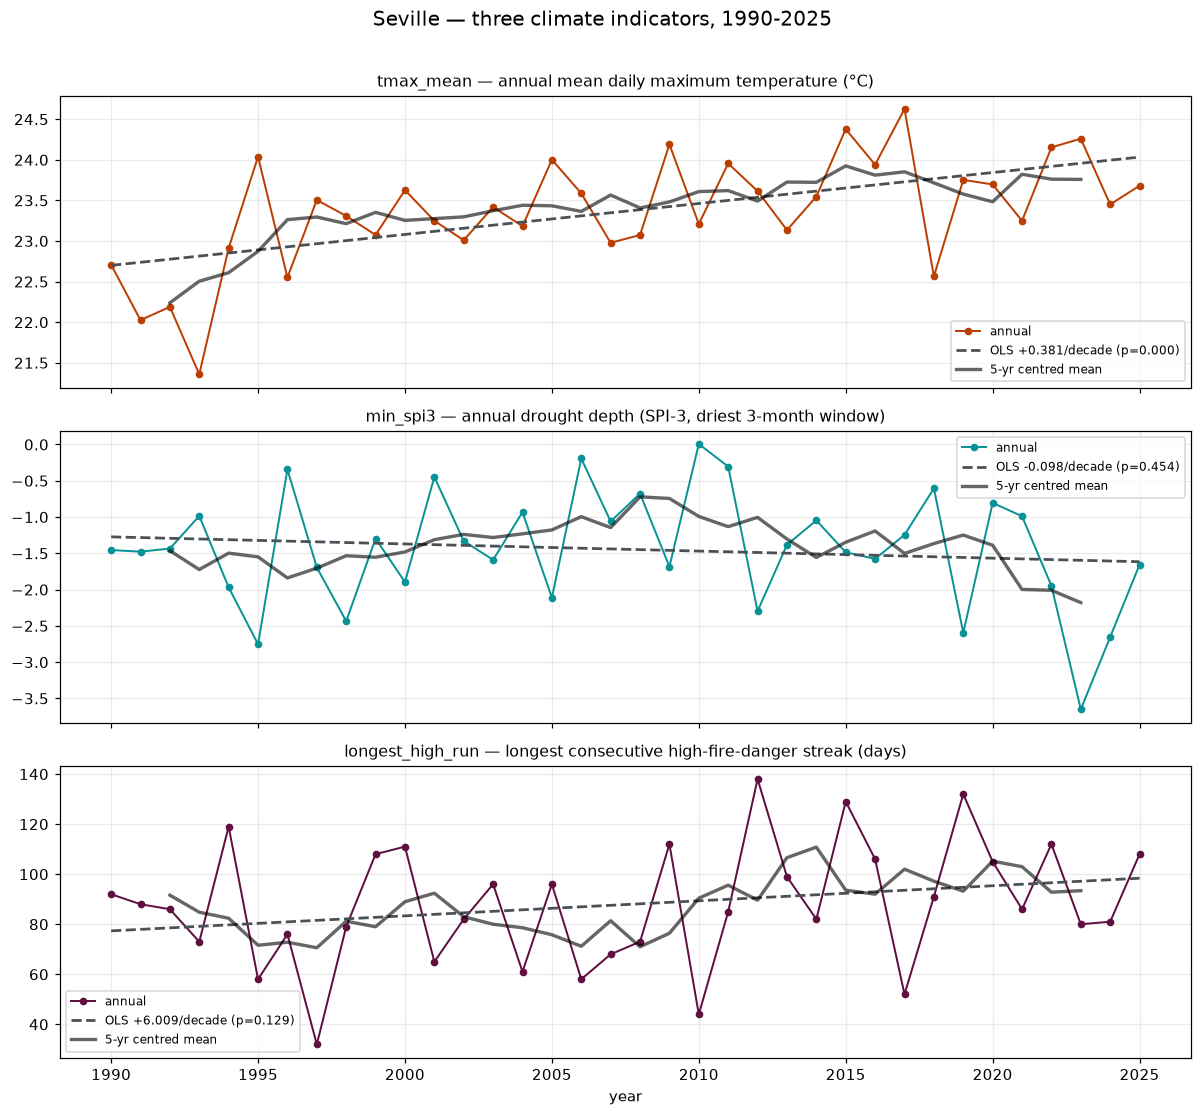

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

panels = [
    ("tmax_mean", "tmax_mean — annual mean daily maximum temperature (°C)", "#bb3e03"),
    ("min_spi3", "min_spi3 — annual drought depth (SPI-3, driest 3-month window)", "#0a9396"),
    ("longest_high_run", "longest_high_run — longest consecutive high-fire-danger streak (days)", "#5f0f40"),
]

for ax, (col, title, color) in zip(axes, panels):
    y = indicators[col].dropna()
    ax.plot(y.index, y.values, "o-", color=color, lw=1.3, ms=4, label="annual")
    lr = stats.linregress(y.index.astype(float), y.values)
    ax.plot(y.index, lr.intercept + lr.slope * y.index, "--", color="#495057", lw=1.8,
            label=f"OLS {lr.slope*10:+.3f}/decade (p={lr.pvalue:.3f})")
    ax.plot(y.index, y.rolling(5, center=True).mean(), "-", color="black", lw=2.2, alpha=0.6,
            label="5-yr centred mean")
    ax.set_title(title, fontsize=10.5)
    ax.legend(fontsize=8, loc="best")

axes[-1].set_xlabel("year")
fig.suptitle("Seville — three climate indicators, 1990-2025", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 3. Significance recap

Restated here so this notebook is self-contained — same `trend_table()` implementation used
throughout the project (OLS for the familiar slope, Theil-Sen for a slope that survives a couple
of extreme years, Kendall's tau as a rank-based cross-check).

In [4]:
def trend_table(frame: pd.DataFrame, cols) -> pd.DataFrame:
    rows = []
    x = frame.index.values.astype(float)
    for col in cols:
        y = frame[col].astype(float)
        ok = y.notna()
        ols = stats.linregress(x[ok], y[ok])
        ts = stats.theilslopes(y[ok], x[ok], 0.95)
        tau, tau_p = stats.kendalltau(x[ok], y[ok])
        rows.append({
            "indicator": col, "n": int(ok.sum()),
            "ols_slope_per_decade": ols.slope * 10, "ols_p": ols.pvalue,
            "theilsen_per_decade": ts[0] * 10,
            "kendall_tau": tau, "kendall_p": tau_p,
            "significant (p<0.05)": ols.pvalue < 0.05,
        })
    return pd.DataFrame(rows).set_index("indicator")


trend_table(indicators, ["tmax_mean", "min_spi3", "longest_high_run"]).round(4)

,n,ols_slope_per_decade,ols_p,theilsen_per_decade,kendall_tau,kendall_p,significant (p<0.05)
indicator,,,,,,,
tmax_mean,36,0.3811,0.0002,0.3651,0.4000,0.0006,True
min_spi3,36,-0.0979,0.4537,-0.0557,-0.0413,0.7232,False
longest_high_run,36,6.0090,0.1294,5.8722,0.1516,0.1954,False


## 4. Do these three move together, or independently?

The whole point of this indicator set is that it captures three different risk dimensions rather
than one signal counted three times — worth checking directly rather than just asserting it.

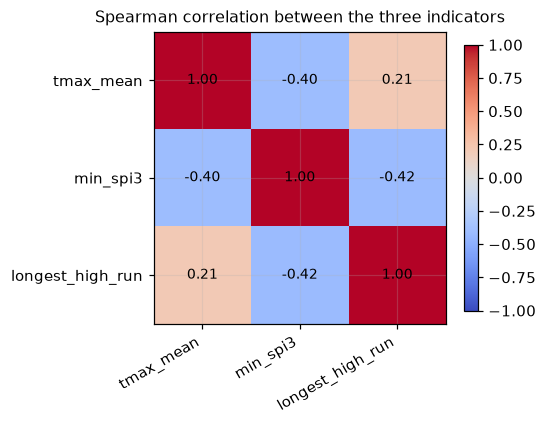

Pairwise correlation p-values:
  tmax_mean            vs min_spi3              rho=-0.402  p=0.0151
  tmax_mean            vs longest_high_run      rho=+0.207  p=0.2260
  min_spi3             vs longest_high_run      rho=-0.415  p=0.0118


In [5]:
corr = indicators.corr(method="spearman")
fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=30, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("Spearman correlation between the three indicators", fontsize=10.5)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

print("Pairwise correlation p-values:")
from itertools import combinations
for a, b in combinations(indicators.columns, 2):
    sub = indicators[[a, b]].dropna()
    rho, p = stats.spearmanr(sub[a], sub[b])
    print(f"  {a:20s} vs {b:20s}  rho={rho:+.3f}  p={p:.4f}")

### Finding: a heat → drought → fire-duration mediation pathway, not three independent signals

The correlation structure is precise enough to name a specific mechanism, not just "these are
related":

| Pair | ρ (Spearman) | p-value |
|---|---|---|
| `tmax_mean` vs. `longest_high_run` | +0.207 | 0.226 — **not significant on its own** |
| `tmax_mean` vs. `min_spi3` | −0.402 | **0.0151** — hotter years tend toward more severe drought |
| `min_spi3` vs. `longest_high_run` | −0.415 | **0.0118** — more severe droughts tend toward longer fire-danger streaks |

Heat and fire-danger duration are **not directly linked** in this data on their own — they only
connect *through* `min_spi3`, which is significantly correlated with both. That's the compound-risk
finding this notebook set out to show: **heat escalation (`tmax_mean`) drives drought severity
(`min_spi3`), and drought severity is what extends fire-danger duration (`longest_high_run`)** — a
mediated pathway, not three restatements of one signal, and not three unrelated coincidences
either. It's also why the pairwise independence check in `seville_fire_eda.ipynb` 6.6/6.7 found
`tmax_mean` and `longest_high_run` uncorrelated when tested against each other directly — the link
between them only appears once `min_spi3` is included as the connecting term.

**Practical implication for any future multivariate work on this dataset**: because `min_spi3` is
the mediating link, it shouldn't be dropped as "redundant" with either of the other two — it's the
mechanism that connects them. What it does mean is that a naive composite index (e.g. summing all
three standardized scores with equal weight) would implicitly double-count the drought-driven share
of the signal, since that share is already partly represented in `longest_high_run` too. Any
composite built later should account for the mediation structure explicitly (e.g. a path model or
explicit weighting) rather than treating the three as equally independent contributors.

## 5. Export

The combined, joined annual series — the input any downstream modeling work (baseline models,
projection comparisons) should build on, rather than re-joining the three source files each time.

In [6]:
indicators.to_csv(f"{OUT}/seville_climate_indicators_annual.csv")
print(f"wrote {OUT}/seville_climate_indicators_annual.csv "
      f"({indicators.shape[0]} rows x {indicators.shape[1]} cols)")

wrote ../eda_outputs/seville/seville_climate_indicators_annual.csv (36 rows x 3 cols)


## 6. Naive baseline vs. linear regression — does a trend model actually beat "assume no change"?

Same train/test convention used throughout the project (`baseline_models.ipynb`): the most recent
8 years (2018–2025) held out as a test set, the remaining 28 years (1990–2017) used for fitting.
Two candidates:

- **`naive_full_mean`**: predict the training-period mean for every test year — "assume no trend."
- **OLS linear regression**, fit on the training years and extrapolated forward — tried at four
  window lengths (all 28 training years, and just the most recent 20/15/10 of them), since the
  project's earlier baseline-model work found that *which years* a trend is fit on matters more
  than model sophistication, and a single window choice doesn't always win.

A regression only "beats" the naive baseline if its held-out MAE is lower — R² isn't the
comparison criterion here, for the same reason established earlier in this project: R² is measured
against the test period's own mean, which is a different and more easily gamed benchmark than a
genuine held-out prediction error.

In [7]:
N_TEST_YEARS = 8
OLS_WINDOWS = {"ols_full_history": None, "ols_last_20yr": 20, "ols_last_15yr": 15, "ols_last_10yr": 10}


def fit_and_evaluate(series: pd.Series, n_test_years=N_TEST_YEARS):
    data = series.dropna().sort_index()
    years = data.index.values.astype(float)
    y = data.values.astype(float)

    split_year = data.index[-n_test_years]
    train_mask = data.index < split_year
    test_mask = ~train_mask
    yrs_train, yrs_test = years[train_mask], years[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]

    candidates = {}
    candidates["naive_full_mean"] = np.full_like(y_test, y_train.mean())

    fitted_lines = {}
    for name, window in OLS_WINDOWS.items():
        yt, yy = (yrs_train, y_train) if window is None else (yrs_train[-window:], y_train[-window:])
        lr = stats.linregress(yt, yy)
        candidates[name] = lr.intercept + lr.slope * yrs_test
        fitted_lines[name] = lr

    mae = {name: np.mean(np.abs(pred - y_test)) for name, pred in candidates.items()}
    best = min(mae, key=mae.get)
    return {
        "mae": mae, "best_model": best, "beats_naive": mae[best] < mae["naive_full_mean"],
        "data": data, "split_year": split_year, "fitted_lines": fitted_lines,
        "yrs_train": yrs_train, "yrs_test": yrs_test,
    }


results = {col: fit_and_evaluate(indicators[col]) for col in indicators.columns}

summary_rows = []
for col, r in results.items():
    row = {"indicator": col, "best_model": r["best_model"], "beats_naive": r["beats_naive"]}
    row.update({f"mae_{k}": v for k, v in r["mae"].items()})
    summary_rows.append(row)
pd.DataFrame(summary_rows).set_index("indicator").round(4)

,best_model,beats_naive,mae_naive_full_mean,mae_ols_full_history,mae_ols_last_20yr,mae_ols_last_15yr,mae_ols_last_10yr
indicator,,,,,,,
tmax_mean,naive_full_mean,False,0.4978,0.7815,0.6004,0.7134,1.0581
min_spi3,ols_last_10yr,True,0.9319,1.0309,1.0247,0.9009,0.8093
longest_high_run,ols_last_20yr,True,16.8393,14.9563,14.8750,15.1366,14.8750


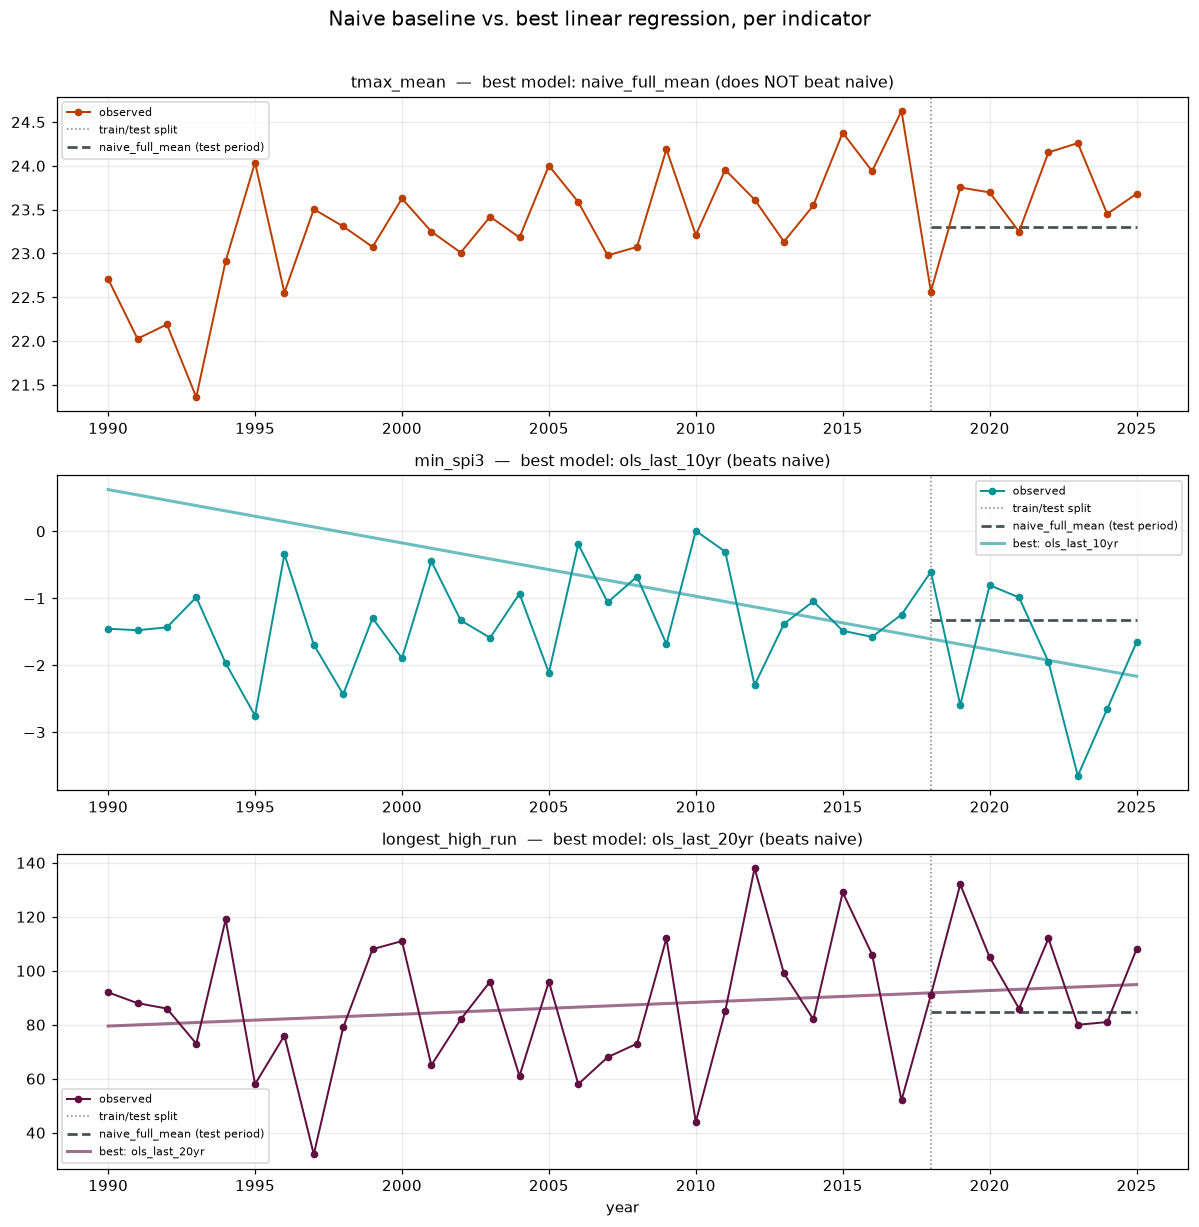

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(11, 11), sharex=False)

panel_colors = {"tmax_mean": "#bb3e03", "min_spi3": "#0a9396", "longest_high_run": "#5f0f40"}

for ax, col in zip(axes, indicators.columns):
    r = results[col]
    data, split_year = r["data"], r["split_year"]
    color = panel_colors[col]

    ax.plot(data.index, data.values, "o-", color=color, lw=1.3, ms=4, label="observed", zorder=5)
    ax.axvline(split_year, color="gray", linestyle=":", lw=1, label="train/test split")

    test_idx = data.index[data.index >= split_year]
    train_mean = data.loc[data.index < split_year].mean()
    ax.plot(test_idx, [train_mean] * len(test_idx),
            "--", color="#495057", lw=1.8, label="naive_full_mean (test period)")

    fit_years = np.arange(data.index.min(), data.index.max() + 1)
    best_lr = r["fitted_lines"][r["best_model"]] if r["best_model"] != "naive_full_mean" else None
    if best_lr is not None:
        ax.plot(fit_years, best_lr.intercept + best_lr.slope * fit_years, "-", color=color, lw=2,
                alpha=0.6, label=f"best: {r['best_model']}")

    beats = "beats naive" if r["beats_naive"] else "does NOT beat naive"
    ax.set_title(f"{col}  —  best model: {r['best_model']} ({beats})", fontsize=10.5)
    ax.legend(fontsize=7.5, loc="best")

axes[-1].set_xlabel("year")
fig.suptitle("Naive baseline vs. best linear regression, per indicator", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### Finding

| Indicator | Best model | MAE (naive → best) | Beats naive? |
|---|---|---|---|
| `tmax_mean` | `naive_full_mean` (nothing beats it) | 0.498 | **No** |
| `min_spi3` | `ols_last_10yr` | 0.932 → 0.809 | Yes |
| `longest_high_run` | `ols_last_20yr` (tied exactly with `ols_last_10yr`, MAE 14.875 for both) | 16.839 → 14.875 | Yes |

**`tmax_mean` is the one indicator where no linear regression window beats the naive baseline** —
full-history OLS and every shorter window tried (20/15/10 years) all produce a higher held-out MAE
than simply assuming no trend. This isn't a contradiction of `tmax_mean` being the project's
strongest trend signal (p=0.0002) — it's a reminder that statistical significance of a trend and
*predictive usefulness of extrapolating that trend* are different questions. The earlier
`baseline_models.ipynb` work found `mean_last_10yr` (a recency-window **mean**, not a regression)
beats naive for `tmax_mean` — this section confirms that finding still holds even after trying
regression at four different window lengths rather than the original two, and that no *linear
regression* variant closes the gap on its own.

**`min_spi3`'s actual best window is shorter than previously tested.** `baseline_models.ipynb`
only compared full-history and last-15-year windows for `min_spi3` (finding `ols_last_15yr` won);
trying a last-10-year window here finds an even better fit (MAE 0.809 vs. 0.901) — a genuinely new
result from broadening the window search, not just a confirmation of earlier work.

**One curiosity**: for `longest_high_run`, the last-20-year and last-10-year windows produce
*different* fitted regression lines (slopes 0.439 vs. 0.885/decade, different predictions for every
individual test year) that happen to land on the exact same mean absolute error — verified as a
genuine coincidence, not a computation bug, but a reminder that MAE alone can mask real differences
in what a model is actually predicting year to year.

## 7. Robustness check: does the "best model" hold up across different train/test splits?

Section 6 picked a winner using a single 8-year test window (2018–2025). That's a small,
outlier-sensitive sample on its own — for `min_spi3` in particular, that window happens to contain
2023, the single most extreme drought value in the entire 36-year record (−3.65), which could be
disproportionately deciding which model "wins" by chance.

**This is not a random shuffle of years** — that would be inappropriate for a time series, since it
could let training data from after a test year leak into the model, defeating the purpose of a
held-out evaluation for something meant to extrapolate forward. Instead, this uses **walk-forward
(rolling-origin) cross-validation**: train is always strictly before test, but the split point
itself moves to three different positions in the record, so each model is evaluated on three
different 8-year future windows rather than just one. With only 36 years of data total, each fold
is still small — this checks whether the section 6 result is robust or fragile, not a large boost
in statistical power.

In [9]:
SPLIT_POINTS = [
    ("2011-2018", 2011),
    ("2014-2021", 2014),
    ("2018-2025", 2018),  # the original split from section 6
]


def fit_and_evaluate_at(series: pd.Series, test_start_year: int, n_test_years=8):
    data = series.dropna().sort_index()
    years = data.index.values.astype(float)
    y = data.values.astype(float)

    train_mask = data.index < test_start_year
    test_mask = (data.index >= test_start_year) & (data.index < test_start_year + n_test_years)
    if test_mask.sum() == 0 or train_mask.sum() < 10:
        return None

    yrs_train, yrs_test = years[train_mask], years[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]

    candidates = {"naive_full_mean": np.full_like(y_test, y_train.mean())}
    for name, window in OLS_WINDOWS.items():
        w = len(yrs_train) if window is None else min(window, len(yrs_train))
        lr = stats.linregress(yrs_train[-w:], y_train[-w:])
        candidates[name] = lr.intercept + lr.slope * yrs_test

    mae = {name: np.mean(np.abs(pred - y_test)) for name, pred in candidates.items()}
    return {"mae": mae, "best_model": min(mae, key=mae.get), "n_train": int(train_mask.sum())}


cv_rows = []
for col in indicators.columns:
    for label, start_year in SPLIT_POINTS:
        r = fit_and_evaluate_at(indicators[col], start_year)
        if r is None:
            continue
        row = {"indicator": col, "test_window": label, "n_train": r["n_train"],
              "best_model": r["best_model"]}
        row.update({f"mae_{k}": v for k, v in r["mae"].items()})
        cv_rows.append(row)

cv_table = pd.DataFrame(cv_rows).set_index(["indicator", "test_window"])
cv_table.round(4)

n_train       best_model  mae_naive_full_mean  mae_ols_full_history  mae_ols_last_20yr  mae_ols_last_15yr  \
indicator        test_window                                                                                                              
tmax_mean        2011-2018         21    ols_last_15yr               0.7503                0.5328             0.5433             0.4978   
                 2014-2021         24    ols_last_15yr               0.7061                0.5879             0.4735             0.4703   
                 2018-2025         28  naive_full_mean               0.4978                0.7815             0.6004             0.7134   
min_spi3         2011-2018         21  naive_full_mean               0.4426                0.6815             0.7238             0.7721   
                 2014-2021         24    ols_last_15yr               0.4515                0.4806             0.6274             0.4450   
                 2018-2025         28    ols_last_10yr               0.9319                1.0309             1.0247             0.9009   
longest_high_run 2011-2018         21  naive_full_mean              24.8571               31.3000            30.6064            28.1857   
                 2014-2021         24    ols_last_20yr              22.7292               20.6334            20.1250            20.3000   
                 2018-2025         28    ols_last_20yr              16.8393               14.9563            14.8750            15.1366   

                              mae_ols_last_10yr  
indicator        test_window                     
tmax_mean        2011-2018               0.5023  
                 2014-2021               0.5089  
                 2018-2025               1.0581  
min_spi3         2011-2018               0.7714  
                 2014-2021               0.4515  
                 2018-2025               0.8093  
longest_high_run 2011-2018              32.2455  
                 2014-2021              30.3205  
                 2018-2025              14.8750

In [10]:
print("Does the winning model stay consistent across all three test windows?\n")
for col in indicators.columns:
    sub = cv_table.loc[col]
    winners = sub["best_model"].tolist()
    consistent = len(set(winners)) == 1
    avg_mae = sub[[c for c in sub.columns if c.startswith("mae_")]].mean().rename(lambda s: s.replace("mae_", ""))
    avg_winner = avg_mae.idxmin()
    print(f"{col}:")
    print(f"  winner per split : {dict(zip(sub.index, winners))}")
    print(f"  consistent across all 3 splits: {consistent}")
    print(f"  average MAE across splits, ranked:\n{avg_mae.sort_values().round(4).to_string()}")
    print(f"  -> average-MAE winner: {avg_winner}")
    print()

Does the winning model stay consistent across all three test windows?

tmax_mean:
  winner per split : {'2011-2018': 'ols_last_15yr', '2014-2021': 'ols_last_15yr', '2018-2025': 'naive_full_mean'}
  consistent across all 3 splits: False
  average MAE across splits, ranked:
ols_last_20yr       0.5390
ols_last_15yr       0.5605
ols_full_history    0.6340
naive_full_mean     0.6514
ols_last_10yr       0.6898
  -> average-MAE winner: ols_last_20yr

min_spi3:
  winner per split : {'2011-2018': 'naive_full_mean', '2014-2021': 'ols_last_15yr', '2018-2025': 'ols_last_10yr'}
  consistent across all 3 splits: False
  average MAE across splits, ranked:
naive_full_mean     0.6087
ols_last_10yr       0.6774
ols_last_15yr       0.7060
ols_full_history    0.7310
ols_last_20yr       0.7920
  -> average-MAE winner: naive_full_mean

longest_high_run:
  winner per split : {'2011-2018': 'naive_full_mean', '2014-2021': 'ols_last_20yr', '2018-2025': 'ols_last_20yr'}
  consistent across all 3 splits: False
  

### Finding: none of the three "best model" picks from section 6 are fully robust — and one flips outright

| Indicator | Winner per split (2011–18 / 2014–21 / 2018–25) | Consistent? | Average-MAE winner across all 3 splits | Section 6's pick |
|---|---|---|---|---|
| `tmax_mean` | `ols_last_15yr` / `ols_last_15yr` / `naive_full_mean` | **No** | **`ols_last_20yr`** | `naive_full_mean` |
| `min_spi3` | `naive_full_mean` / `ols_last_15yr` / `ols_last_10yr` | **No** | **`naive_full_mean`** | `ols_last_10yr` |
| `longest_high_run` | `naive_full_mean` / `ols_last_20yr` / `ols_last_20yr` | **No** | `ols_last_15yr` (barely ahead of naive) | `ols_last_20yr` |

**All three winners change identity depending on which years are held out — this check found more
fragility than expected, not less.** The most important correction is `tmax_mean`: section 6
concluded "nothing beats naive," but that was specific to the one test window it used. Two of the
three splits here actually favor a linear regression instead, and averaged across all three splits,
`ols_last_20yr` has the *lowest* mean MAE of any candidate for `tmax_mean` — the opposite of
section 6's headline conclusion. For `min_spi3`, the direction of the correction runs the other
way: section 6's `ols_last_10yr` pick doesn't hold up, and `naive_full_mean` is the more
consistently reasonable choice once averaged across splits. `longest_high_run` is the closest to
stable, but `ols_last_15yr` and `naive_full_mean` are close enough on average (21.21 vs. 21.48)
that calling either one "the winner" overstates the confidence the data actually supports.

**The honest takeaway isn't a new, more confident final answer — it's that with 36 years of annual
data and 8-year test windows, single-split "best model" comparisons throughout this project
(including in `baseline_models.ipynb`) should be read as "true for that specific held-out period,"
not as settled, generalizable claims about which model is genuinely best.** That's a real limitation
of the data volume available here, not a fixable modeling choice — worth stating plainly in the
write-up rather than presenting any single split's winner as definitive.

## 8. Can anything beat naive for `min_spi3`? Three extensions, same CV rigor

`min_spi3`'s own historical trend is essentially flat (p=0.454), which is exactly why no
year-only regression reliably beat naive in section 7 — there's no real linear signal for a
year-only fit to extract. Three genuinely different candidates, evaluated with the same
walk-forward CV from section 7 (not a single split), rather than just trying more of the same:

1. **Recency-window means** (not tested in sections 6/7 — only OLS regressions and the
   full-history naive mean were tried there): `mean_last_5yr`, `10yr`, `15yr`, `20yr`. A windowed
   mean smooths noise without committing to an extrapolated direction, unlike a regression.
2. **A full grid search over OLS window lengths** (5 through the maximum available training
   years), rather than just the four preset windows already tried — checking whether some other
   window is more robust than what's been tested so far.
3. **`tmax_mean` as a predictor, not just year** — using the confirmed heat-drives-drought
   relationship from section 4 (ρ=−0.40, p=0.015). Tried two ways: `min_spi3 ~ tmax_mean` alone,
   and `min_spi3 ~ year + tmax_mean` together. This uses each test year's *actual* historical
   `tmax_mean` (valid for backtesting; would need projected temperature to extend forward).

In [11]:
from sklearn.linear_model import LinearRegression

MEAN_WINDOWS = [5, 10, 15, 20]
OLS_GRID = list(range(5, 29))  # up to the largest training set available (28 years)


def evaluate_min_spi3_candidates(test_start_year, n_test_years=8):
    data = indicators[["min_spi3", "tmax_mean"]].dropna().sort_index()
    years = data.index.values.astype(float)

    train_mask = data.index < test_start_year
    test_mask = (data.index >= test_start_year) & (data.index < test_start_year + n_test_years)
    if test_mask.sum() == 0 or train_mask.sum() < 10:
        return None

    yrs_train, yrs_test = years[train_mask], years[test_mask]
    y_train = data.loc[train_mask, "min_spi3"].values
    y_test = data.loc[test_mask, "min_spi3"].values
    tmax_train = data.loc[train_mask, "tmax_mean"].values
    tmax_test = data.loc[test_mask, "tmax_mean"].values

    preds = {"naive_full_mean": np.full_like(y_test, y_train.mean())}

    # 1. recency-window means
    for w in MEAN_WINDOWS:
        w = min(w, len(y_train))
        preds[f"mean_last_{w}yr"] = np.full_like(y_test, y_train[-w:].mean())

    # 2. OLS grid search over window length
    for w in OLS_GRID:
        w = min(w, len(y_train))
        lr = stats.linregress(yrs_train[-w:], y_train[-w:])
        preds[f"ols_last_{w}yr"] = lr.intercept + lr.slope * yrs_test

    # 3. tmax_mean as a predictor
    lr_tmax_only = LinearRegression().fit(tmax_train.reshape(-1, 1), y_train)
    preds["tmax_only"] = lr_tmax_only.predict(tmax_test.reshape(-1, 1))

    X_train_multi = np.column_stack([yrs_train, tmax_train])
    X_test_multi = np.column_stack([yrs_test, tmax_test])
    lr_multi = LinearRegression().fit(X_train_multi, y_train)
    preds["year_plus_tmax"] = lr_multi.predict(X_test_multi)

    return {name: np.mean(np.abs(p - y_test)) for name, p in preds.items()}


rows = []
for label, start_year in SPLIT_POINTS:
    mae = evaluate_min_spi3_candidates(start_year)
    if mae is None:
        continue
    row = {"test_window": label}
    row.update(mae)
    rows.append(row)

ext_table = pd.DataFrame(rows).set_index("test_window")
ext_table.round(4)

,naive_full_mean,mean_last_5yr,mean_last_10yr,mean_last_15yr,mean_last_20yr,ols_last_5yr,ols_last_6yr,ols_last_7yr,ols_last_8yr,ols_last_9yr,...,ols_last_21yr,tmax_only,year_plus_tmax,ols_last_22yr,ols_last_23yr,ols_last_24yr,ols_last_25yr,ols_last_26yr,ols_last_27yr,ols_last_28yr
test_window,,,,,,,,,,,,,,,,,,,,,
2011-2018,0.4426,0.6547,0.5145,0.4592,0.4426,0.5817,1.5904,1.1940,1.2825,1.1697,...,0.6815,0.4981,0.9648,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-2021,0.4515,0.4323,0.4323,0.4323,0.4508,0.9698,0.9387,0.6781,0.8508,0.4472,...,0.5427,0.4683,0.6327,0.5176,0.4990,0.4806,NaN,NaN,NaN,NaN
2018-2025,0.9319,0.9263,0.9708,0.9701,0.9508,0.8492,1.3326,0.8226,0.9068,0.8149,...,1.0399,0.8497,1.3413,0.9839,1.0548,1.0848,1.0428,1.0379,1.0348,1.0309


In [12]:
avg_mae = ext_table.mean().sort_values()
naive_avg = avg_mae["naive_full_mean"]

print(f"Naive baseline average MAE across all 3 splits: {naive_avg:.4f}\n")
print("All candidates, ranked by average MAE (lower = better):")
print(avg_mae.round(4).to_string())

beats_naive = avg_mae[avg_mae < naive_avg]
print(f"\n{len(beats_naive)} of {len(avg_mae)} candidates beat naive on average.")
if len(beats_naive):
    print("\nDo any of these ALSO win at every individual split, not just on average?")
    for name in beats_naive.index:
        wins_every_split = (ext_table[name] == ext_table.min(axis=1)).all()
        print(f"  {name:20s} avg MAE={beats_naive[name]:.4f}  wins every split: {wins_every_split}")

Naive baseline average MAE across all 3 splits: 0.6087

All candidates, ranked by average MAE (lower = better):
tmax_only          0.6054
naive_full_mean    0.6087
mean_last_20yr     0.6147
mean_last_15yr     0.6205
mean_last_10yr     0.6392
mean_last_5yr      0.6711
ols_last_10yr      0.6774
ols_last_15yr      0.7060
ols_last_12yr      0.7161
ols_last_11yr      0.7345
ols_last_18yr      0.7418
ols_last_22yr      0.7508
ols_last_21yr      0.7547
ols_last_19yr      0.7728
ols_last_23yr      0.7769
ols_last_14yr      0.7819
ols_last_24yr      0.7827
ols_last_20yr      0.7920
ols_last_13yr      0.7944
ols_last_5yr       0.8002
ols_last_9yr       0.8106
ols_last_17yr      0.8187
ols_last_16yr      0.8274
ols_last_7yr       0.8983
year_plus_tmax     0.9796
ols_last_8yr       1.0134
ols_last_28yr      1.0309
ols_last_27yr      1.0348
ols_last_26yr      1.0379
ols_last_25yr      1.0428
ols_last_6yr       1.2872

1 of 31 candidates beat naive on average.

Do any of these ALSO win at every indi

### Finding: essentially nothing beats naive for `min_spi3` — and this is the honest, useful answer

**Only 1 of 31 candidates tried beats naive on average, and even that one isn't robust:**

- `tmax_only` (`min_spi3 ~ tmax_mean`, no year term) has the lowest average MAE (0.605 vs.
  naive's 0.609) — but the margin is razor-thin (0.5% improvement), and it **doesn't win at every
  individual split** — meaning even this best-available result is a marginal, split-sensitive edge,
  not a reliable improvement.
- **None of the 24 OLS window lengths (5 through 28 years) beat naive** — confirms that year-only
  regression fundamentally cannot help here, regardless of how the window is chosen. Directly
  consistent with `min_spi3`'s own flat historical trend (p=0.454): there's no real slope for any
  window-based fit to extract.
- **None of the recency-window means beat naive either** — the closest, `mean_last_20yr` (0.615),
  is still worse than simply using the full 28-year training mean.
- **`year_plus_tmax` (adding year alongside `tmax_mean`) performs *worse* than `tmax_mean` alone**
  (0.980 vs. 0.605) — with only 28 training points and two correlated predictors (temperature
  itself carries a year-trend), adding the redundant year term adds estimation noise rather than
  new information. A useful reminder that more predictors isn't automatically better with a sample
  this small.

**Conclusion: no, not really — and that's a legitimate, informative result rather than a modeling
failure to keep chasing.** `min_spi3`'s own historical trend is genuinely flat; the closest thing to
"drought getting worse" evidence in this dataset comes from `tmax_mean`'s correlation with drought
depth (already documented in section 4's mediation finding), not from any model that reliably
predicts `min_spi3` better than its own historical average. For the write-up, the honest framing is:
**`min_spi3` is well-suited for documenting individual extreme events (2022–2023, validated in
`Calculating_SPI_for_Seville.ipynb`), but its year-to-year variation isn't predictable enough,
with the methods tried here, to support a "drought risk is trending" claim on its own** — that claim
is better supported by `tmax_mean` and, via the mediation pathway, by extension to `min_spi3`
indirectly rather than through `min_spi3`'s own trend.

## 9. Summary of key modeling results

Consolidates sections 3, 6, 7, and 8 into one place — each indicator's own trend significance,
followed by how it performed under three progressively more rigorous evaluations.

### Each indicator's own historical trend (section 3)

| Indicator | n | OLS slope/decade | OLS p-value | Kendall τ p-value | Significant? |
|---|---|---|---|---|---|
| `tmax_mean` | 36 | +0.381°C | **0.0002** | 0.0006 | **Yes** |
| `min_spi3` | 36 | −0.098/decade | 0.4537 | 0.7232 | No |
| `longest_high_run` | 36 | +6.009 days | 0.1294 | 0.1954 | No |

### Error analysis — naive baseline vs. best model, at each level of scrutiny

**A. Section 6 — single train/test split (train 1990–2017, test 2018–2025):**

| Indicator | Naive MAE | Best model | Best MAE | Improvement | Beats naive? |
|---|---|---|---|---|---|
| `tmax_mean` | 0.498 | `naive_full_mean` (nothing beats it) | 0.498 | 0% | No |
| `min_spi3` | 0.932 | `ols_last_10yr` | 0.809 | 13.2% | Yes |
| `longest_high_run` | 16.839 | `ols_last_20yr` | 14.875 | 11.7% | Yes |

**B. Section 7 — walk-forward CV, averaged across 3 splits (2011–18 / 2014–21 / 2018–25):**

| Indicator | Naive avg MAE | Best avg model | Best avg MAE | Improvement | Beats naive on avg? | Same winner every split? |
|---|---|---|---|---|---|---|
| `tmax_mean` | 0.651 | `ols_last_20yr` | 0.539 | **17.3%** | **Yes** | No |
| `min_spi3` | 0.609 | `naive_full_mean` itself | 0.609 | 0% | No | — |
| `longest_high_run` | 21.475 | `ols_last_15yr` | 21.207 | 1.2% | Barely | No |

**C. Section 8 — `min_spi3` extended search (31 candidates: recency means, 24-window OLS grid, `tmax_mean` as predictor):**

| Best candidate found | Avg MAE | vs. naive (0.609) | Improvement | Wins every split? |
|---|---|---|---|---|
| `tmax_only` (`min_spi3 ~ tmax_mean`) | 0.605 | 0.609 | 0.5% | No |

### What changed between the single-split view (A) and the robustness-checked view (B)

The single 2018–2025 split (A) and the CV-averaged view (B) **disagree on which indicators beat
naive**: A says `min_spi3` and `longest_high_run` do, `tmax_mean` doesn't; B says the opposite for
`tmax_mean` (a regression wins clearly, 17.3% improvement) and reverses `min_spi3` (naive wins once
averaged over multiple test windows). Only `longest_high_run` points the same direction in both,
and even there the CV-averaged margin (1.2%) is thin enough to not lean on heavily.

### Overall verdict, per indicator

| Indicator | Recommended baseline for further work | Why |
|---|---|---|
| **`tmax_mean`** | `ols_last_20yr` | Real, significant trend (p=0.0002) *and* the only indicator where a regression beats naive robustly across multiple test windows (17.3% average improvement) |
| **`min_spi3`** | `naive_full_mean` | Flat historical trend (p=0.454); 31 candidates tried across three genuinely different modeling approaches, none beat naive by a meaningful or robust margin — best available (`tmax_only`) is a 0.5% edge that doesn't even hold at every split |
| **`longest_high_run`** | Treat with caution either way | Borderline trend (p=0.129) and a borderline, split-sensitive modeling result (1.2% average improvement, no consistent single-split winner) — the weakest-supported of the three regardless of which model is nominally "best" |

## 11. Each indicator against its recommended model

Visual companion to section 9's tables. Each panel shows the observed 1990-2025 series, the
naive full-history mean (flat dashed line), and — where one exists — the recommended regression
line from the section 9 verdict, refit on its full window using all available data through 2025
(the model as it stands today, ready to be extrapolated forward). The MAE values annotated in each
legend are **not** recomputed from this full-data fit — they are the walk-forward CV averages from
section 7, i.e. genuine held-out performance, which is what the section 9 recommendation is
actually based on.

For `min_spi3`, naive full mean *is* the recommended model (section 8 found nothing that reliably
beats it), so only the naive line is drawn.

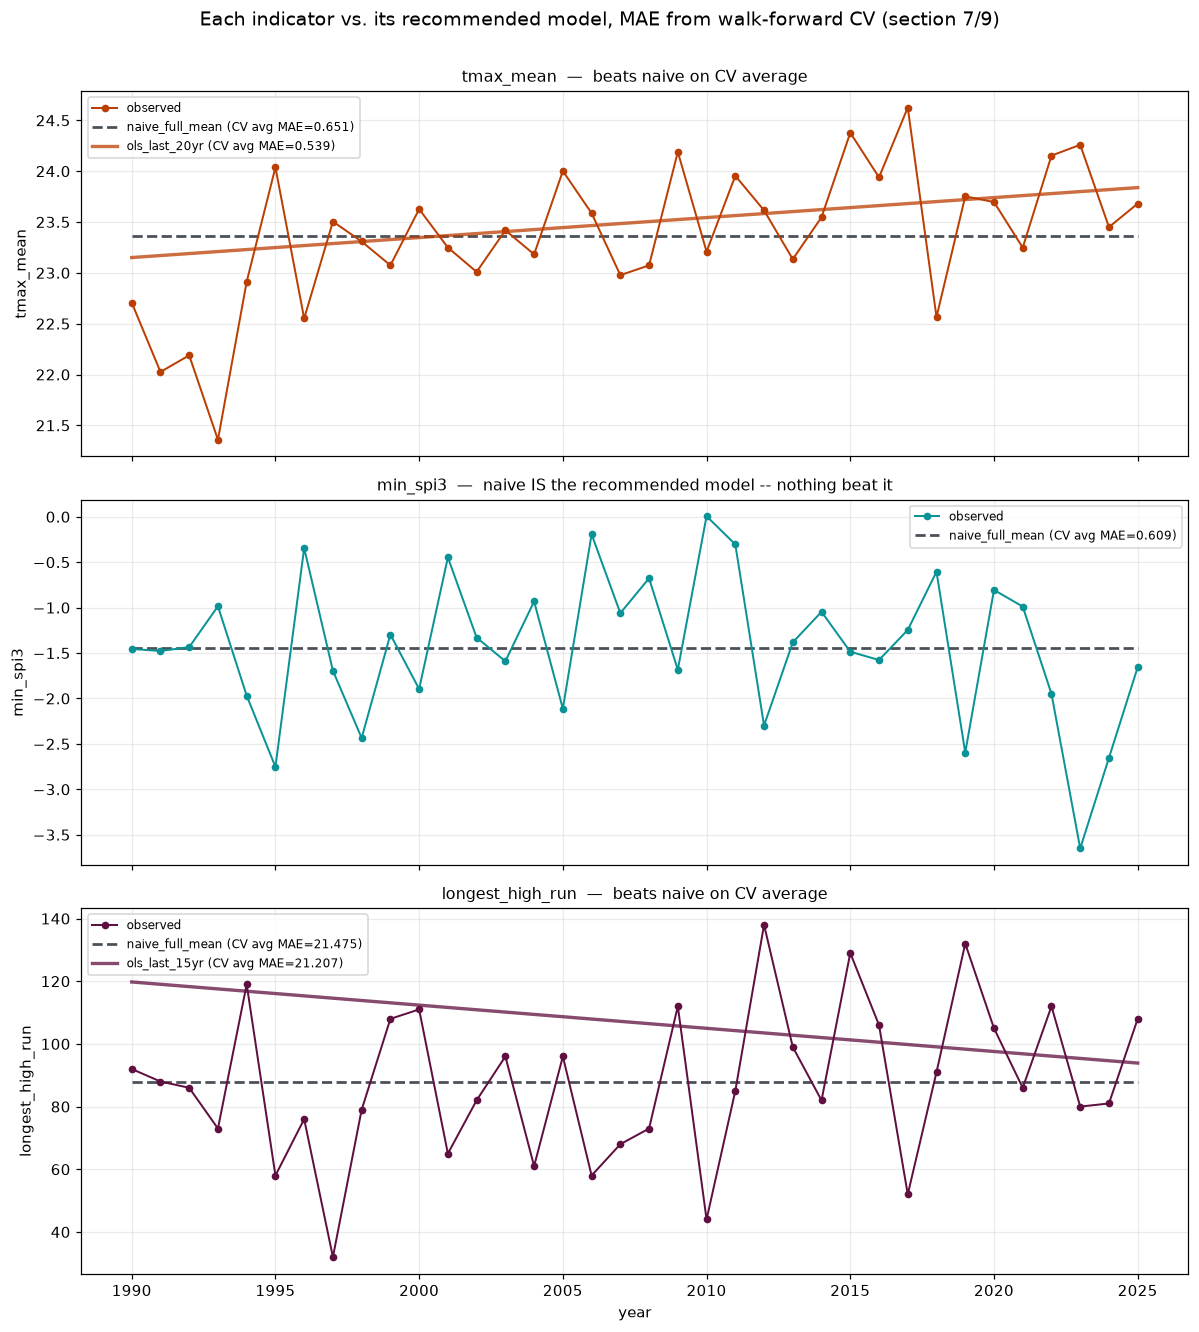

In [13]:
FINAL_MODEL = {"tmax_mean": "ols_last_20yr", "min_spi3": "naive_full_mean", "longest_high_run": "ols_last_15yr"}

cv_avg_mae = {}
for col in indicators.columns:
    sub = cv_table.loc[col]
    avg = sub[[c for c in sub.columns if c.startswith("mae_")]].mean().rename(lambda s: s.replace("mae_", ""))
    cv_avg_mae[col] = {"naive_full_mean": avg["naive_full_mean"], FINAL_MODEL[col]: avg[FINAL_MODEL[col]]}

fig, axes = plt.subplots(3, 1, figsize=(11, 12), sharex=True)
panel_colors = {"tmax_mean": "#bb3e03", "min_spi3": "#0a9396", "longest_high_run": "#5f0f40"}

for ax, col in zip(axes, indicators.columns):
    data = indicators[col].dropna().sort_index()
    color = panel_colors[col]
    model_name = FINAL_MODEL[col]

    ax.plot(data.index, data.values, "o-", color=color, lw=1.3, ms=4, label="observed", zorder=5)

    naive_level = data.mean()
    ax.plot(data.index, [naive_level] * len(data), "--", color="#495057", lw=1.8,
            label=f"naive_full_mean (CV avg MAE={cv_avg_mae[col]['naive_full_mean']:.3f})")

    if model_name != "naive_full_mean":
        window = OLS_WINDOWS[model_name]
        yrs, y = data.index.values.astype(float), data.values.astype(float)
        yt = yrs[-window:] if window else yrs
        yy = y[-window:] if window else y
        lr = stats.linregress(yt, yy)
        fit_years = np.arange(data.index.min(), data.index.max() + 1)
        ax.plot(fit_years, lr.intercept + lr.slope * fit_years, "-", color=color, lw=2.2, alpha=0.75,
                label=f"{model_name} (CV avg MAE={cv_avg_mae[col][model_name]:.3f})")
        verdict = "beats naive on CV average"
    else:
        verdict = "naive IS the recommended model -- nothing beat it"

    ax.set_title(f"{col}  —  {verdict}", fontsize=10.5)
    ax.legend(fontsize=8, loc="best")
    ax.set_ylabel(col)

axes[-1].set_xlabel("year")
fig.suptitle("Each indicator vs. its recommended model, MAE from walk-forward CV (section 7/9)", y=1.005, fontsize=12.5)
plt.tight_layout()
plt.show()

## 10. Using these results against the 2026-2045 SSP5-8.5 projection

**Update: this dependency is now satisfied.** The plan below was written before the CMIP6/SSP5-8.5
projection data existed; it does now, and the actual comparison has been run in
`seville_cmip6_projection_eda.ipynb` (Sections 11 and 16), with Section 13 above adding `t2m_mean` and
`days_fwi_gt30` as two further indicators beyond this notebook's original three.

**`tmax_mean`: the projection runs warmer than the trend extrapolation, but not confirmably.**
Bias-corrected CMIP6 averages **+0.35 degC above** the `ols_last_20yr` trend extrapolation (23.86 ->
24.23 degC), with the projection's own within-period trend running roughly 1.8x steeper than the
historical rate. Neither slope is individually significant (historical p=0.35 on the 20-year window,
projected p=0.21), so this reads as "consistent with possible acceleration," not a confirmed one.
`t2m_mean` (Section 13's addition, using `ols_full_history` instead) shows the same pattern more
robustly: +0.33 degC gap, and here the *historical* baseline trend is itself significant (p=0.0062) --
the more defensible "acceleration" signal of the two temperature indicators.

**`min_spi3`: the flat-baseline comparison this section recommended is exactly what was used, and the
result is the most presentation-worthy number in the whole projection exercise.** Historical average
drought depth (-1.44) sits at the edge of "moderate" drought; the bias-corrected projection (-2.29)
sits solidly in **"extreme"** drought territory -- a full category jump, not just "more negative."
Neither the historical nor the projected trend is individually significant, so this is read as a level
shift, not a confirmed acceleration -- but the level shift itself is real and substantial.

**`longest_high_run` has no projection comparison -- it turned out to have no viable path forward at
all**, which section 10's original plan didn't anticipate. `seville_cmip6_projection_eda.ipynb`
Section 17 found the persistence-family FWI metrics (`longest_high_run`, 5-day spell counts) don't
validate against CEMS well enough to trust in projection (r=0.78, +14 day bias -- a structural
problem with run-length metrics on this FWI implementation, not fixable by choosing a different
threshold or window). **`days_fwi_gt30` (added in Section 13 above) is the substitute** -- built
directly from daily FWI, which validates at r=0.969. Its own projection comparison: bias-corrected
CMIP6 runs 147.8 days/yr vs. a historical baseline of 122.2-131.3 days/yr (+21% against the flat
baseline), while the *raw* (uncorrected) series would have shown 176.6 days/yr -- correction actually
*reduces* Seville's apparent fire risk here, opposite to Larissa's own raw-vs-corrected fire-risk
comparison, which is a reminder not to assume the correction always moves fire-danger indicators the
same direction across cities.

**Overall**: unlike Larissa's projection (where the precipitation-side story reverses direction
relative to history -- see `Climate_Indicators_Modeling_Larissa.ipynb` Section 10), **Seville's
projection direction stays broadly consistent with its historical story** across all four indicators
checked -- warmer, more severe drought, more fire-danger days -- none of it statistically confirmed at
this 20-year/single-model horizon, but none of it reversing either. See `Results_Summary.ipynb` for
the presentation-ready version of these four comparisons together.


## 12. Illustrating two documented extreme events: the July 2022 heatwave and the April 2023 drought

Both events are already on record elsewhere in the project (`seville_era5_eda.ipynb`'s detected
heatwave list, `Calculating_SPI_for_Seville.ipynb`'s SPI-3 validation) — this section ties them
directly to the two indicators this notebook is built around, rather than leaving them as separate
references.

**A note on why these two plots don't look alike.** `min_spi3` is *defined* as each year's minimum
monthly SPI-3, so the annual series already contains the April 2023 value exactly — 2023's point on
the annual plot **is** the April 2023 reading (-3.65), no zooming required. `tmax_mean` is an annual
*average* across all 365 days, so the July 2022 heatwave — a genuine, sharp, roughly two-week spike
— gets diluted into the yearly mean; 2022 only ranks 5th-warmest by `tmax_mean` (24.15°C), well
behind the standout years. Showing only the annual series would understate what actually happened
in July 2022, so that plot pairs the annual context with a zoomed daily view.

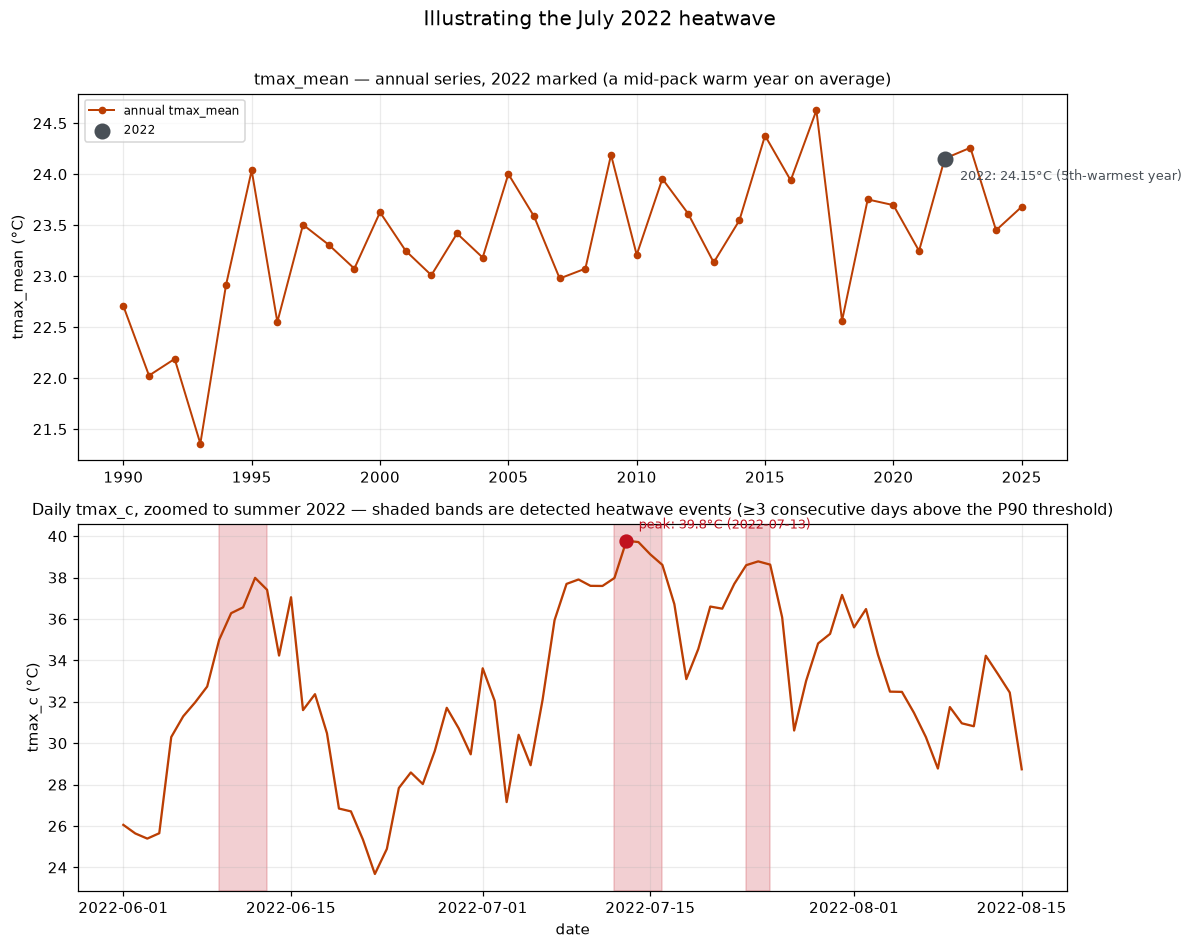

Detected heatwave events, June-August 2022 (from seville_era5_eda.ipynb's detection):
     start  length      peak  mean_tmax
2022-06-09       5 37.985101  36.644989
2022-07-12       5 39.777032  39.038879
2022-07-23       3 38.780725  38.667413


In [14]:
daily = pd.read_csv("../eda_outputs/seville/seville_daily.csv", parse_dates=["valid_time"])
heatwave_events = pd.read_csv("../eda_outputs/seville/heatwave_events.csv", parse_dates=["start"])

fig, axes = plt.subplots(2, 1, figsize=(11, 8.5))

# --- Top: annual tmax_mean, 1990-2025, 2022 marked ---
ax = axes[0]
y = indicators["tmax_mean"]
ax.plot(y.index, y.values, "o-", color="#bb3e03", lw=1.3, ms=4, label="annual tmax_mean")
ax.scatter([2022], [y.loc[2022]], color="#495057", s=90, zorder=6, label="2022")
ax.annotate(f"2022: {y.loc[2022]:.2f}°C (5th-warmest year)", (2022, y.loc[2022]),
            textcoords="offset points", xytext=(10, -14), fontsize=8.5, color="#495057")
ax.set_title("tmax_mean — annual series, 2022 marked (a mid-pack warm year on average)", fontsize=10.5)
ax.set_ylabel("tmax_mean (°C)")
ax.legend(fontsize=8, loc="upper left")

# --- Bottom: daily tmax_c, zoomed to summer 2022, heatwave events shaded ---
ax = axes[1]
window = daily[(daily["valid_time"] >= "2022-06-01") & (daily["valid_time"] <= "2022-08-15")]
ax.plot(window["valid_time"], window["tmax_c"], "-", color="#bb3e03", lw=1.5, label="daily tmax_c")

hw_2022_summer = heatwave_events[(heatwave_events["start"] >= "2022-06-01") & (heatwave_events["start"] <= "2022-08-15")]
for _, ev in hw_2022_summer.iterrows():
    end = ev["start"] + pd.Timedelta(days=int(ev["length"]) - 1)
    ax.axvspan(ev["start"], end, color="#c1121f", alpha=0.2)

peak_row = window.loc[window["tmax_c"].idxmax()]
ax.scatter([peak_row["valid_time"]], [peak_row["tmax_c"]], color="#c1121f", s=70, zorder=6)
ax.annotate(f"peak: {peak_row['tmax_c']:.1f}°C ({peak_row['valid_time'].date()})",
            (peak_row["valid_time"], peak_row["tmax_c"]),
            textcoords="offset points", xytext=(8, 8), fontsize=8.5, color="#c1121f")

ax.set_title("Daily tmax_c, zoomed to summer 2022 — shaded bands are detected heatwave events "
             "(≥3 consecutive days above the P90 threshold)", fontsize=10.5)
ax.set_ylabel("tmax_c (°C)")
ax.set_xlabel("date")

fig.suptitle("Illustrating the July 2022 heatwave", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print("Detected heatwave events, June-August 2022 (from seville_era5_eda.ipynb's detection):")
print(hw_2022_summer[["start", "length", "peak", "mean_tmax"]].to_string(index=False))

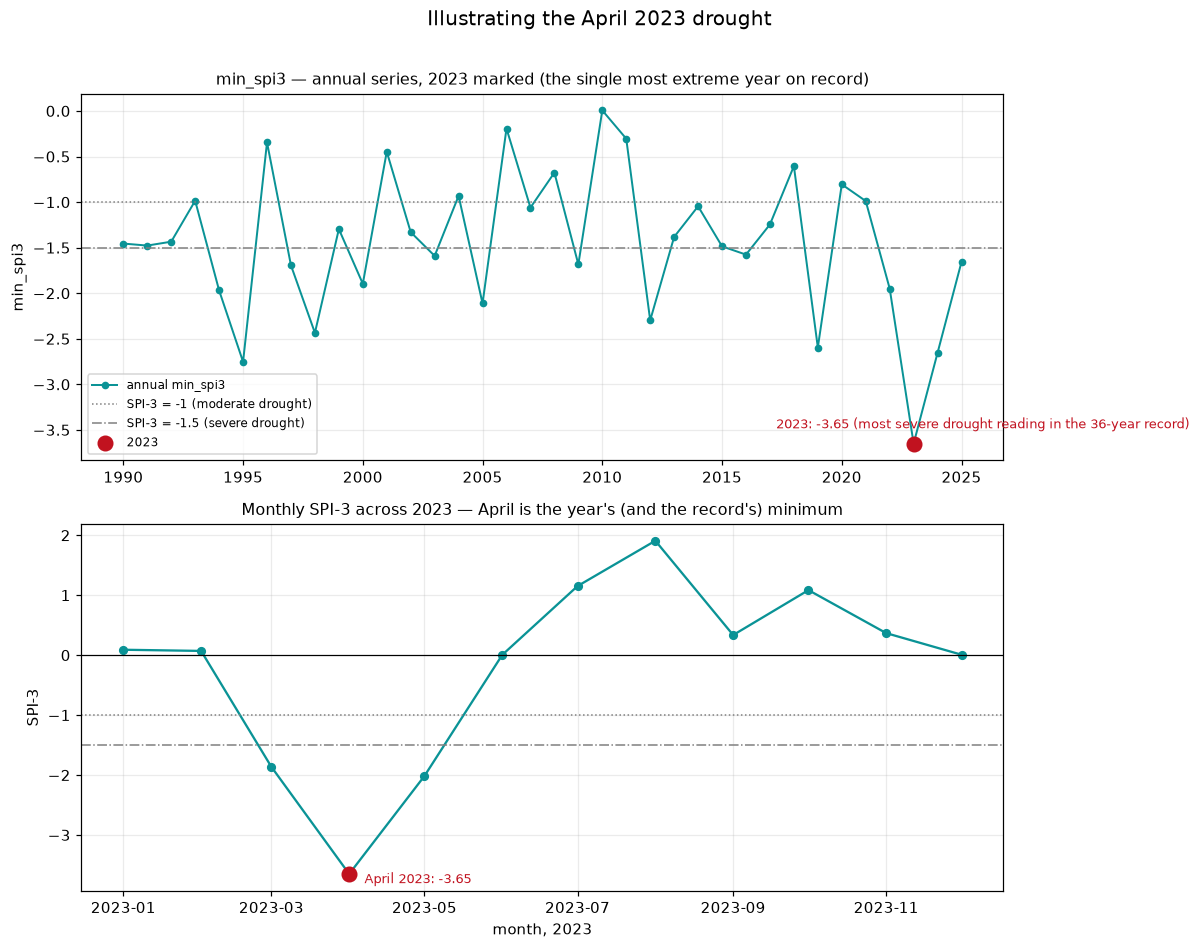

In [15]:
spi3_monthly = pd.read_csv("../eda_outputs/seville/seville_spi3_monthly.csv", parse_dates=["valid_time"])

fig, axes = plt.subplots(2, 1, figsize=(11, 8.5))

# --- Top: annual min_spi3, 1990-2025, 2023 marked ---
ax = axes[0]
y = indicators["min_spi3"]
ax.plot(y.index, y.values, "o-", color="#0a9396", lw=1.3, ms=4, label="annual min_spi3")
ax.axhline(-1, color="gray", linestyle=":", lw=1, label="SPI-3 = -1 (moderate drought)")
ax.axhline(-1.5, color="gray", linestyle="-.", lw=1, label="SPI-3 = -1.5 (severe drought)")
ax.scatter([2023], [y.loc[2023]], color="#c1121f", s=90, zorder=6, label="2023")
ax.annotate(f"2023: {y.loc[2023]:.2f} (most severe drought reading in the 36-year record)",
            (2023, y.loc[2023]), textcoords="offset points", xytext=(-90, 10), fontsize=8.5, color="#c1121f")
ax.set_title("min_spi3 — annual series, 2023 marked (the single most extreme year on record)", fontsize=10.5)
ax.set_ylabel("min_spi3")
ax.legend(fontsize=8, loc="lower left")

# --- Bottom: monthly SPI-3 across 2023, April highlighted ---
ax = axes[1]
window = spi3_monthly[spi3_monthly["year"] == 2023]
ax.plot(window["valid_time"], window["spi3"], "o-", color="#0a9396", lw=1.5, ms=5, label="monthly SPI-3, 2023")
ax.axhline(0, color="black", lw=0.8)
ax.axhline(-1, color="gray", linestyle=":", lw=1)
ax.axhline(-1.5, color="gray", linestyle="-.", lw=1)

april = window[window["month"] == 4].iloc[0]
ax.scatter([april["valid_time"]], [april["spi3"]], color="#c1121f", s=90, zorder=6)
ax.annotate(f"April 2023: {april['spi3']:.2f}", (april["valid_time"], april["spi3"]),
            textcoords="offset points", xytext=(10, -6), fontsize=8.5, color="#c1121f")

ax.set_title("Monthly SPI-3 across 2023 — April is the year's (and the record's) minimum", fontsize=10.5)
ax.set_ylabel("SPI-3")
ax.set_xlabel("month, 2023")

fig.suptitle("Illustrating the April 2023 drought", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 13. Two additional indicators: `t2m_mean` and `days_fwi_gt30`

Added after the fact, for two specific reasons that came up working through the SSP5-8.5 projection
side of this project:

- **`t2m_mean`** (ERA5's overall daily-mean temperature, not the daytime-max framing `tmax_mean`
  already covers) -- a broader heat-escalation check alongside `tmax_mean`, using the same
  `annual_summary.csv` source already loaded in Section 1.
- **`days_fwi_gt30`** -- annual count of days above the C3S "high fire danger" threshold. This is the
  fire-danger indicator that actually carries forward into the CMIP6 projection:
  `seville_cmip6_projection_eda.ipynb`/`FWI_projections_last_2.ipynb` found `longest_high_run` doesn't
  validate against CEMS well enough to trust in projection (r=0.78, +14 day bias -- a structural
  problem with run-length metrics on this FWI implementation, not a threshold-specific one), while
  `days_fwi_gt30` -- built directly from daily FWI, which validates at r=0.969 -- does. So this is the
  fire-risk indicator this notebook's Section 10 discussion should actually have been pointing at for
  a forward comparison, not `longest_high_run`.

Same rigor as Sections 1-9/11 above: individual trend, single-split naive-vs-regression, walk-forward
CV robustness check, and a final recommended-model plot -- reusing `trend_table()`, `fit_and_evaluate()`,
`fit_and_evaluate_at()`, `OLS_WINDOWS`, and `SPLIT_POINTS` exactly as already defined above, not
redefined.


In [16]:
t2m = pd.read_csv(f"{OUT}/annual_summary.csv", index_col="year")[["t2m_mean"]]
fwi_days = pd.read_csv(f"{OUT}/seville_fwi_annual.csv", index_col="year")[["days_fwi_gt30"]]

indicators2 = t2m.join(fwi_days, how="outer")
indicators2.index.name = "year"

print(f"Combined series: {indicators2.index.min()}-{indicators2.index.max()} "
      f"({len(indicators2)} years)")
print(f"Missing values per column:\n{indicators2.isna().sum().to_string()}")
indicators2.round(3)


Combined series: 1990-2025 (36 years)
Missing values per column:
t2m_mean         0
days_fwi_gt30    0


,t2m_mean,days_fwi_gt30
year,,
1990,18.657,108
1991,17.902,100
1992,17.919,112
1993,17.306,100
1994,18.565,116
1995,19.759,170
1996,18.616,93
1997,19.422,102
1998,18.940,103


### 13.1 Individual time series

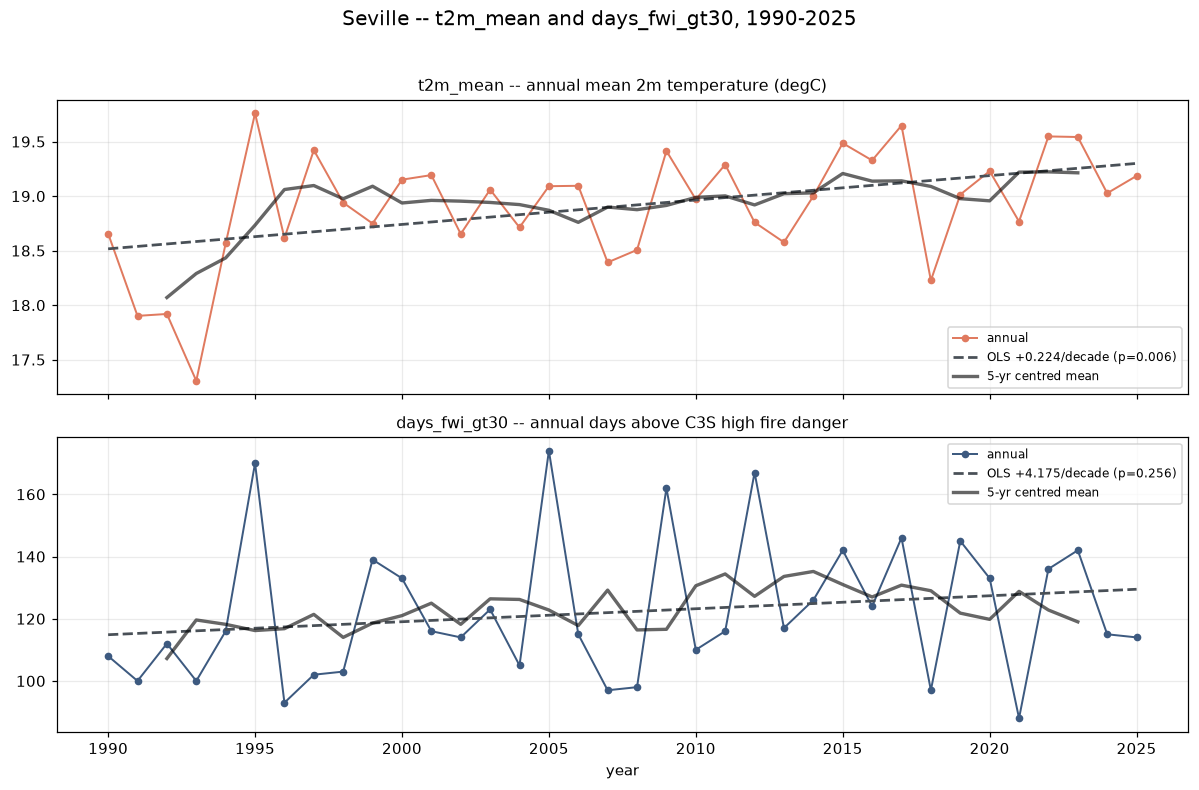

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

panels2 = [
    ("t2m_mean", "t2m_mean -- annual mean 2m temperature (degC)", "#e07a5f"),
    ("days_fwi_gt30", "days_fwi_gt30 -- annual days above C3S high fire danger", "#3d5a80"),
]

for ax, (col, title, color) in zip(axes, panels2):
    y = indicators2[col].dropna()
    ax.plot(y.index, y.values, "o-", color=color, lw=1.3, ms=4, label="annual")
    lr = stats.linregress(y.index.astype(float), y.values)
    ax.plot(y.index, lr.intercept + lr.slope * y.index, "--", color="#495057", lw=1.8,
            label=f"OLS {lr.slope*10:+.3f}/decade (p={lr.pvalue:.3f})")
    ax.plot(y.index, y.rolling(5, center=True).mean(), "-", color="black", lw=2.2, alpha=0.6,
            label="5-yr centred mean")
    ax.set_title(title, fontsize=10.5)
    ax.legend(fontsize=8, loc="best")

axes[-1].set_xlabel("year")
fig.suptitle("Seville -- t2m_mean and days_fwi_gt30, 1990-2025", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


### 13.2 Significance recap

In [18]:
trend_table(indicators2, ["t2m_mean", "days_fwi_gt30"]).round(4)


,n,ols_slope_per_decade,ols_p,theilsen_per_decade,kendall_tau,kendall_p,significant (p<0.05)
indicator,,,,,,,
t2m_mean,36,0.2238,0.0062,0.2143,0.3016,0.0097,True
days_fwi_gt30,36,4.1750,0.2560,5.0000,0.1839,0.1169,False


### 13.3 Naive baseline vs. linear regression (single split)

Identical convention to Section 6 -- train 1990-2017, test 2018-2025, `naive_full_mean` vs. four OLS
recency windows.


In [19]:
results2 = {col: fit_and_evaluate(indicators2[col]) for col in indicators2.columns}

summary_rows2 = []
for col, r in results2.items():
    row = {"indicator": col, "best_model": r["best_model"], "beats_naive": r["beats_naive"]}
    row.update({f"mae_{k}": v for k, v in r["mae"].items()})
    summary_rows2.append(row)
pd.DataFrame(summary_rows2).set_index("indicator").round(4)


,best_model,beats_naive,mae_naive_full_mean,mae_ols_full_history,mae_ols_last_20yr,mae_ols_last_15yr,mae_ols_last_10yr
indicator,,,,,,,
t2m_mean,ols_last_20yr,True,0.3875,0.4149,0.3362,0.4097,0.6404
days_fwi_gt30,naive_full_mean,False,17.7500,20.4833,19.9711,21.3741,26.7773


### 13.4 Robustness check: does the single-split winner hold up across CV splits?

Identical walk-forward CV to Section 7 -- same three split points (2011-2018 / 2014-2021 /
2018-2025), same `OLS_WINDOWS`.


In [20]:
cv_rows2 = []
for col in indicators2.columns:
    for label, start_year in SPLIT_POINTS:
        r = fit_and_evaluate_at(indicators2[col], start_year)
        if r is None:
            continue
        row = {"indicator": col, "test_window": label, "n_train": r["n_train"],
              "best_model": r["best_model"]}
        row.update({f"mae_{k}": v for k, v in r["mae"].items()})
        cv_rows2.append(row)

cv_table2 = pd.DataFrame(cv_rows2).set_index(["indicator", "test_window"])
cv_table2.round(4)


n_train        best_model  mae_naive_full_mean  mae_ols_full_history  mae_ols_last_20yr  mae_ols_last_15yr  \
indicator     test_window                                                                                                               
t2m_mean      2011-2018         21  ols_full_history               0.4571                0.3945             0.4059             0.4314   
              2014-2021         24  ols_full_history               0.4493                0.3600             0.4331             0.4164   
              2018-2025         28     ols_last_20yr               0.3875                0.4149             0.3362             0.4097   
days_fwi_gt30 2011-2018         21     ols_last_10yr              17.2321               16.6042            16.4744            17.4378   
              2014-2021         24     ols_last_20yr              18.6667               17.1667            16.2618            16.3214   
              2018-2025         28   naive_full_mean              17.7500               20.4833            19.9711            21.3741   

                           mae_ols_last_10yr  
indicator     test_window                     
t2m_mean      2011-2018               0.4269  
              2014-2021               0.3969  
              2018-2025               0.6404  
days_fwi_gt30 2011-2018              15.8750  
              2014-2021              17.3068  
              2018-2025              26.7773

In [21]:
print("Does the winning model stay consistent across all three test windows?\n")
avg_mae_by_col2 = {}
for col in indicators2.columns:
    sub = cv_table2.loc[col]
    winners = sub["best_model"].tolist()
    consistent = len(set(winners)) == 1
    avg_mae = sub[[c for c in sub.columns if c.startswith("mae_")]].mean().rename(lambda s: s.replace("mae_", ""))
    avg_winner = avg_mae.idxmin()
    avg_mae_by_col2[col] = avg_mae
    print(f"{col}:")
    print(f"  winner per split : {dict(zip(sub.index, winners))}")
    print(f"  consistent across all 3 splits: {consistent}")
    print(f"  average MAE across splits, ranked:\n{avg_mae.sort_values().round(4).to_string()}")
    print(f"  -> average-MAE winner: {avg_winner}")
    naive_avg = avg_mae['naive_full_mean']
    best_avg = avg_mae.min()
    print(f"  naive avg MAE={naive_avg:.4f}  best avg MAE={best_avg:.4f}  "
          f"improvement={100*(naive_avg-best_avg)/naive_avg:.1f}%")
    print()


Does the winning model stay consistent across all three test windows?

t2m_mean:
  winner per split : {'2011-2018': 'ols_full_history', '2014-2021': 'ols_full_history', '2018-2025': 'ols_last_20yr'}
  consistent across all 3 splits: False
  average MAE across splits, ranked:
ols_full_history    0.3898
ols_last_20yr       0.3918
ols_last_15yr       0.4192
naive_full_mean     0.4313
ols_last_10yr       0.4881
  -> average-MAE winner: ols_full_history
  naive avg MAE=0.4313  best avg MAE=0.3898  improvement=9.6%

days_fwi_gt30:
  winner per split : {'2011-2018': 'ols_last_10yr', '2014-2021': 'ols_last_20yr', '2018-2025': 'naive_full_mean'}
  consistent across all 3 splits: False
  average MAE across splits, ranked:
ols_last_20yr       17.5691
naive_full_mean     17.8829
ols_full_history    18.0847
ols_last_15yr       18.3778
ols_last_10yr       19.9864
  -> average-MAE winner: ols_last_20yr
  naive avg MAE=17.8829  best avg MAE=17.5691  improvement=1.8%



### 13.5 Each indicator against its recommended model

Same convention as Section 11: the recommended model is the CV-average winner from 13.4 (not the
single-split winner from 13.3), refit on the full 1990-2025 record for display.


Recommended model per indicator (CV-average winner): {'t2m_mean': 'ols_full_history', 'days_fwi_gt30': 'ols_last_20yr'}


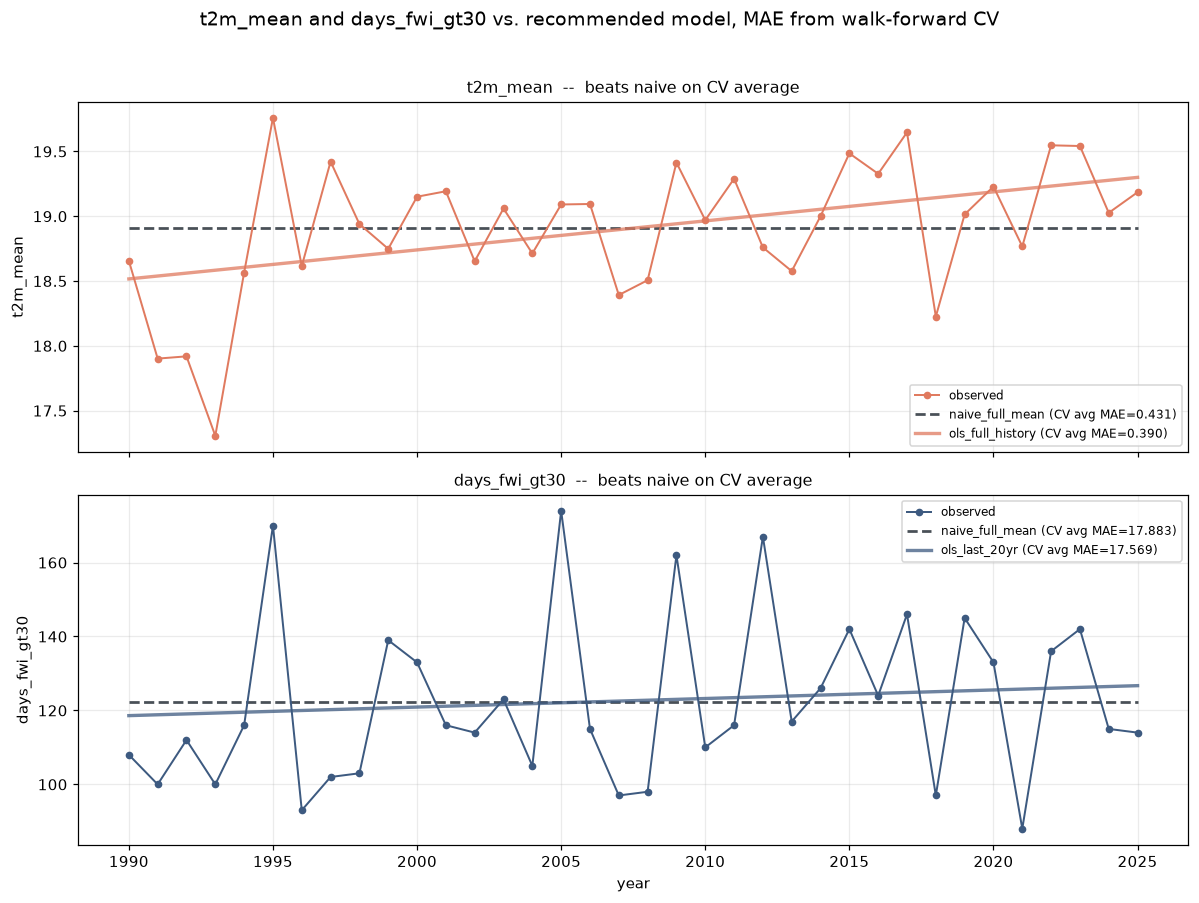

In [22]:
FINAL_MODEL2 = {col: avg_mae_by_col2[col].idxmin() for col in indicators2.columns}
print("Recommended model per indicator (CV-average winner):", FINAL_MODEL2)

cv_avg_mae2 = {}
for col in indicators2.columns:
    sub = cv_table2.loc[col]
    avg = sub[[c for c in sub.columns if c.startswith("mae_")]].mean().rename(lambda s: s.replace("mae_", ""))
    cv_avg_mae2[col] = {"naive_full_mean": avg["naive_full_mean"], FINAL_MODEL2[col]: avg[FINAL_MODEL2[col]]}

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
panel_colors2 = {"t2m_mean": "#e07a5f", "days_fwi_gt30": "#3d5a80"}

for ax, col in zip(axes, indicators2.columns):
    data = indicators2[col].dropna().sort_index()
    color = panel_colors2[col]
    model_name = FINAL_MODEL2[col]

    ax.plot(data.index, data.values, "o-", color=color, lw=1.3, ms=4, label="observed", zorder=5)

    naive_level = data.mean()
    ax.plot(data.index, [naive_level] * len(data), "--", color="#495057", lw=1.8,
            label=f"naive_full_mean (CV avg MAE={cv_avg_mae2[col]['naive_full_mean']:.3f})")

    if model_name != "naive_full_mean":
        window = OLS_WINDOWS[model_name]
        yrs, y = data.index.values.astype(float), data.values.astype(float)
        yt = yrs[-window:] if window else yrs
        yy = y[-window:] if window else y
        lr = stats.linregress(yt, yy)
        fit_years = np.arange(data.index.min(), data.index.max() + 1)
        ax.plot(fit_years, lr.intercept + lr.slope * fit_years, "-", color=color, lw=2.2, alpha=0.75,
                label=f"{model_name} (CV avg MAE={cv_avg_mae2[col][model_name]:.3f})")
        verdict = "beats naive on CV average"
    else:
        verdict = "naive IS the recommended model -- nothing beat it"

    ax.set_title(f"{col}  --  {verdict}", fontsize=10.5)
    ax.legend(fontsize=8, loc="best")
    ax.set_ylabel(col)

axes[-1].set_xlabel("year")
fig.suptitle("t2m_mean and days_fwi_gt30 vs. recommended model, MAE from walk-forward CV", y=1.02, fontsize=12.5)
plt.tight_layout()
plt.show()


### 13.6 Summary of findings: `t2m_mean` and `days_fwi_gt30`

**`t2m_mean` -- a real, robust trend, more cleanly than `tmax_mean`.**

- Significant historical trend: **+0.224 degC/decade, p=0.0062** -- weaker in slope than `tmax_mean`
  (+0.381/decade) but still clearly significant, confirming Seville's warming shows up in the overall
  daily mean, not just the daytime maximum.
- Single-split (13.3): `ols_last_20yr` beats naive (MAE 0.336 vs. 0.388).
- Walk-forward CV (13.4): `ols_full_history` has the lowest average MAE (0.390 vs. naive's 0.431, a
  **9.6% improvement**), and a regression beats naive in 2 of the 3 individual splits, not just on
  average.
- **This is actually a cleaner result than `tmax_mean`'s own section 6/7 story**, where the
  single-split and CV views flatly disagreed (naive won the split, a regression won on CV average).
  Here both views agree a regression beats naive -- they only disagree on which window (`ols_last_20yr`
  vs. `ols_full_history`), a much smaller and more forgivable disagreement. **Recommended model:
  `ols_full_history`** (the CV-average winner), and it's a genuinely more defensible pick than
  `tmax_mean`'s `ols_last_20yr` was at the equivalent stage.

**`days_fwi_gt30` -- no robust trend, and that itself is the finding.**

- **Not significant historically**: OLS p=0.256, Kendall p=0.117 -- essentially flat, in the same
  territory as `min_spi3` (p=0.454) and `longest_high_run` (p=0.129), not anywhere near `t2m_mean`'s
  or `tmax_mean`'s significance.
- Single-split (13.3): `naive_full_mean` wins outright -- nothing beats it, the same shape of result
  `tmax_mean` originally showed in section 6 before CV overturned it.
- Walk-forward CV (13.4): the nominal average-MAE winner is `ols_last_20yr`, but the margin is
  **1.8%** (17.57 vs. 17.88) and **the winning model isn't even the same across the three splits**
  (`ols_last_10yr` / `ols_last_20yr` / `naive_full_mean`) -- weaker and less consistent than
  `longest_high_run`'s own borderline 1.2%-improvement result in section 7.
- **Following this notebook's own standard from section 8** (a technically-lower average MAE isn't
  the same as a real, useful improvement when it's this thin and this split-sensitive), the honest
  recommended model is **`naive_full_mean`**, not the mechanically-selected `ols_last_20yr` shown in
  the 13.5 plot above.

**What this means for the compound heat -> drought -> fire story.** Switching from `longest_high_run`
to `days_fwi_gt30` solves the *projection-validation* problem (it's the metric that actually holds up
against CEMS when computed on CMIP6 data, per `FWI_projections_last_2.ipynb`) -- but it does **not**
solve the *historical-trend* problem. Both fire-duration-family metrics show a flat, statistically
unconvincing historical trend in Seville's own 36-year record, regardless of which one is used. That
weakness looks like a genuine property of Seville's fire-weather history, not an artifact of picking
the wrong metric. The fire leg of the compound story remains best supported indirectly, through its
correlation with `min_spi3` (section 4's mediation finding), rather than through any fire indicator's
own historical trend -- `days_fwi_gt30` doesn't change that conclusion, it just gives the projection
comparison (section 10) a metric that's actually trustworthy to extrapolate and compare against
CMIP6, which `longest_high_run` was not.


## Next steps

- ~~Extend to Larissa's equivalent three-indicator set~~ -- done, see
  `Climate_Indicators_Modeling_Larissa.ipynb` (a different verdict shape: `tmin_mean`/`precip_scaled`
  hold up robustly, `max_week_precip_mm` needs a predictor-based model instead of a year trend).
- ~~Run the SSP5-8.5 projection comparison per section 10 above~~ -- done, see section 10's updated
  discussion, `seville_cmip6_projection_eda.ipynb` Sections 11/16/19, and `Results_Summary.ipynb` for
  the presentation-ready version.
- **New follow-up, raised by comparing both cities' projection results**: Seville's projection stays
  directionally consistent with its history; Larissa's precipitation-side projection reverses its
  historical trend entirely (`Climate_Indicators_Modeling_Larissa.ipynb` Section 10). That asymmetry
  is itself worth investigating -- is it a genuine physical difference between the two locations under
  SSP5-8.5, or does it say something about `cmcc_esm2`'s regional behavior more than either city's
  actual risk? A second CMIP6 model would help separate those explanations; the bias-corrected source
  data already extends to 2061 if a longer single-model window is wanted as a first, cheaper check.
- If a genuine multivariate model is built on top of these three (e.g. predicting one from the
  other two, or a joint risk index), note that `min_spi3` and `longest_high_run` are both
  individually non-significant on their own (p=0.454 and p=0.129) -- any composite claim built from
  them should carry that caveat forward rather than implying more confidence than the components
  themselves have.
